CV libraries in pytorch:

- torchvision
- torchvision.datasets - data loader
- torchvision.models - pretrained cv models
- torchvision.transforms - func for data manipulation
- torch.utils.data.Dataset - base dataset class for pytorch
- torch.utils.data.Dataloader - a python iterable over a dataset

In [52]:
import torch
import torch.nn as nn
import torchvision
import torchvision.datasets as ds
import torchvision.transforms as tr
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [53]:
train_data = ds.FashionMNIST(
    root='data', #where data downloaded
    train=True, #want train dataset
    download=True, #download dataset
    transform=ToTensor(), #data format, in our case torch tensor
    target_transform=None
)

In [54]:
test_data = ds.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [55]:
len(train_data), len(test_data)

(60000, 10000)

In [56]:
samples = [train_data[i] for i in range(10)]
images = [s[0] for s in samples]
labels = [s[1] for s in samples]

In [57]:
images

[tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [58]:
labels

[9, 0, 0, 3, 0, 2, 7, 2, 5, 5]

In [59]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

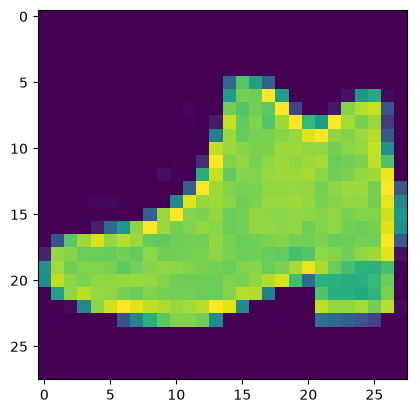

In [60]:
image, label = train_data[15]
plt.imshow(image.squeeze())

In [61]:
torch.manual_seed(42)

In [62]:
train_loader = DataLoader(
    dataset=train_data,
    batch_size=32, #divides a dataset into this size of # and we get 60000/32 # of batches
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=32,
    shuffle=False
)

In [63]:
train_loader.dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [64]:
train_loader.__len__() # a number per batch

1875

In [65]:
train_features_batch, train_labels_batch = next(iter(train_loader))

In [66]:
flatten_model = nn.Flatten()
x = train_features_batch[0]
output = flatten_model(x)

In [67]:
class FashionMNISTV0(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int
                 ):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )

    def forward(self, x):
        return self.layer_stack(x)

In [68]:
torch.manual_seed(42)

model_0 = FashionMNISTV0(input_shape=784, hidden_units=10, output_shape=len(class_names)).to('cuda')

In [69]:
model_0

FashionMNISTV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [70]:
dummy_x = torch.rand([1, 1, 28, 28]).to('cuda')
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [71]:
from sklearn.metrics import accuracy_score

In [72]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

In [73]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_0 = model_0.to(device)

from tqdm.auto import tqdm

epochs = 3
for epoch in tqdm(range(epochs)):
    model_0.train()
    train_loss = 0
    for batch, (X, y) in enumerate(train_loader):
        X, y = X.to(device), y.to(device)  # <-- добавить сюда
        y_pred = model_0(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f"{batch * len(X)}/{len(train_loader.dataset)} samples")

    train_loss /= len(train_loader)

    test_loss, test_acc = 0, 0
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            test_pred = model_0(X)
            test_loss += loss_fn(test_pred, y).item()          # .item() достаёт число
            test_acc += accuracy_score(y.to('cpu'), test_pred.argmax(dim=1).to('cpu'))

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

    print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

  0%|          | 0/3 [00:00<?, ?it/s]

0/60000 samples
12800/60000 samples
25600/60000 samples
38400/60000 samples
51200/60000 samples


 33%|███▎      | 1/3 [00:06<00:13,  6.74s/it]

Epoch: 0 | Train loss: 0.6248 | Test loss: 0.5123 | Test acc: 0.8222
0/60000 samples
12800/60000 samples
25600/60000 samples
38400/60000 samples
51200/60000 samples


 67%|██████▋   | 2/3 [00:15<00:07,  7.89s/it]

Epoch: 1 | Train loss: 0.4615 | Test loss: 0.4801 | Test acc: 0.8324
0/60000 samples
12800/60000 samples
25600/60000 samples
38400/60000 samples
51200/60000 samples


100%|██████████| 3/3 [00:21<00:00,  7.33s/it]

Epoch: 2 | Train loss: 0.4368 | Test loss: 0.4784 | Test acc: 0.8316


In [74]:
next(model_0.parameters())

Parameter containing:
tensor([[-0.0016,  0.1198,  0.1060,  ...,  0.0539, -0.0610,  0.0826],
        [-0.1974, -0.0447, -0.1967,  ...,  0.1096,  0.1403,  0.0206],
        [-0.0320,  0.0981, -0.0629,  ...,  0.1024,  0.0530,  0.0699],
        ...,
        [ 0.0197,  0.0103,  0.1598,  ...,  0.2606,  0.3912,  0.1187],
        [-0.0885, -0.0469, -0.1998,  ..., -0.2237, -0.1696, -0.1558],
        [-0.1267, -0.0244, -0.0595,  ..., -0.2811, -0.3374, -0.1685]],
       device='cuda:0', requires_grad=True)

In [75]:
def eval_model(model: nn.Module, data_loader: DataLoader, loss_fn: nn.Module, accuracy_fn):
    """Return a dictionary containing the results of model predicting on data loader"""
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in tqdm(data_loader):
            X, y = X.to('cuda'), y.to('cuda')
            #Make predictions
            y_pred = model(X)
            loss += loss_fn(y_pred, y).item()
            acc += accuracy_fn(y.to('cpu'), y_pred.argmax(dim=1).to('cpu'))

    loss /= len(data_loader)
    acc /= len(data_loader)

    return {
        'model_name': model.__class__.__name__,
        "model_loss": loss,
        "model_accuracy": acc
    }

In [76]:
model_0_results = eval_model(model_0, test_dataloader, loss_fn, accuracy_score)

100%|██████████| 313/313 [00:00<00:00, 358.54it/s]


In [77]:
model_0_results

{'model_name': 'FashionMNISTV0',
 'model_loss': 0.4784093759120844,
 'model_accuracy': 0.8315694888178914}

In [78]:
def train_step(model: nn.Module,
                data_loader: DataLoader,
                loss_fn: nn.Module,
                optimizer: torch.optim.Optimizer,
                accuracy_fn,
                device: torch.device = device):
    """Performs a training step with model trying to learn on data_loader"""
    train_loss, train_acc = 0, 0
    model.train()
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y.to('cpu'), y_pred.argmax(dim=1).to('cpu'))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f"{batch * len(X)}/{len(data_loader.dataset)} samples")

    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    return train_loss, train_acc


def test_step(model: nn.Module,
              data_loader: DataLoader,
              loss_fn: nn.Module,
              accuracy_fn,
              device: torch.device = device):
    """Performs a testing step on data_loader"""
    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            test_pred = model(X)
            test_loss += loss_fn(test_pred, y).item()
            test_acc += accuracy_fn(y.to('cpu'), test_pred.argmax(dim=1).to('cpu'))

    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")
    return test_loss, test_acc

In [84]:
class FashionMNISTV2(nn.Module):
    """Model architecture that replicates TinyVGG"""
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.cv1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                        kernel_size=3,
                        stride=1,
                        padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.cv2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                        kernel_size=3,
                        stride=1,
                        padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 7*7,
                      out_features=output_shape)
        )

    def forward(self, X):
        X = self.cv1(X)
        X = self.cv2(X)
        return self.classifier(X)

In [85]:
images, labels = next(iter(train_loader))

In [94]:
model_2 = FashionMNISTV2(input_shape=images.shape[1], hidden_units=10, output_shape=len(train_loader.dataset.classes)).to(device)

In [95]:
loss_fn_2 = nn.CrossEntropyLoss()
optimizer_2 = torch.optim.Adam(model_2.parameters(), lr=0.001)

In [96]:
epochs = 30
for epoch in tqdm(range(epochs)):
    print(f'Epoch: {epoch}\n--------')
    train_step(model_2, train_loader, loss_fn_2, optimizer_2, accuracy_score, device)

    test_step(model_2, test_dataloader, loss_fn_2, accuracy_score, device)

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch: 0
--------
0/60000 samples
12800/60000 samples
25600/60000 samples
38400/60000 samples
51200/60000 samples
Train loss: 0.5227 | Train acc: 0.8118


  3%|▎         | 1/30 [00:13<06:43, 13.92s/it]

Test loss: 0.3850 | Test acc: 0.8592
Epoch: 1
--------
0/60000 samples
12800/60000 samples
25600/60000 samples
38400/60000 samples
51200/60000 samples
Train loss: 0.3466 | Train acc: 0.8754


  7%|▋         | 2/30 [00:24<05:26, 11.67s/it]

...

Test loss: 0.2688 | Test acc: 0.9089
Epoch: 28
--------
0/60000 samples
12800/60000 samples
25600/60000 samples
38400/60000 samples
51200/60000 samples
Train loss: 0.1710 | Train acc: 0.9370


 97%|█████████▋| 29/30 [05:57<00:09,  9.45s/it]

Test loss: 0.2627 | Test acc: 0.9094
Epoch: 29
--------
0/60000 samples
12800/60000 samples
25600/60000 samples
38400/60000 samples
51200/60000 samples
Train loss: 0.1704 | Train acc: 0.9383


100%|██████████| 30/30 [06:06<00:00, 12.21s/it]

Test loss: 0.2665 | Test acc: 0.9082


In [98]:
model_2_results = eval_model(model_2, test_dataloader, loss_fn, accuracy_score)
model_2_results

100%|██████████| 313/313 [00:01<00:00, 206.65it/s]


{'model_name': 'FashionMNISTV2',
 'model_loss': 0.2665349655686476,
 'model_accuracy': 0.9082468051118211}

In [99]:
import pandas as pd

df = pd.DataFrame([
    model_0_results, model_2_results
])
df

,model_name,model_loss,model_accuracy
0,FashionMNISTV0,0.478409,0.831569
1,FashionMNISTV2,0.266535,0.908247


In [102]:
from sklearn.metrics import confusion_matrix, classification_report

model_2.eval()

y_preds = []
y_true = []

with torch.inference_mode():
    for X, y in tqdm(test_dataloader):
        X, y = X.to(device), y.to(device)

        logits = model_2(X)
        preds = torch.argmax(logits, dim=1)
        y_preds.extend(preds.cpu().numpy())
        y_true.extend(y.cpu().numpy())

cm = confusion_matrix(y_true, y_preds)
cr = classification_report(y_true, y_preds)
print(cm), print(cr)

100%|██████████| 313/313 [00:01<00:00, 292.69it/s]

[[851   0  16  18   6   1  98   0  10   0]
 [  1 983   0  10   2   0   2   0   2   0]
 [ 12   1 843   9  73   0  60   0   2   0]
 [ 18   3   5 913  43   0  16   0   2   0]
 [  0   1  29  19 899   0  51   0   1   0]
 [  0   0   0   1   0 972   0  20   1   6]
 [113   0  53  29  95   0 702   0   8   0]
 [  0   0   0   0   0  12   0 971   0  17]
 [  4   0   1   2   2   0   4   1 985   1]
 [  0   0   0   0   0   6   0  30   1 963]]
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1000
           1       0.99      0.98      0.99      1000
           2       0.89      0.84      0.87      1000
           3       0.91      0.91      0.91      1000
           4       0.80      0.90      0.85      1000
           5       0.98      0.97      0.98      1000
           6       0.75      0.70      0.73      1000
           7       0.95      0.97      0.96      1000
           8       0.97      0.98      0.98      1000
           9       0.98     

(None, None)